In [2]:
#AIs impact on jobs project
#Part A: Data Understanding & Exploration

In [3]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


In [4]:
df = pd.read_csv("AI_Impact_on_Jobs_2030.csv")
df.head(10)
df.shape
df.info()
# df.describe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              3000 non-null   object 
 1   Job_Title                3000 non-null   object 
 2   Industry                 3000 non-null   object 
 3   Country                  3000 non-null   object 
 4   Education_Level          3000 non-null   object 
 5   Years_Experience         3000 non-null   int64  
 6   AI_Replacement_Risk      3000 non-null   float64
 7   Future_Demand_Score      3000 non-null   float64
 8   Remote_Work_Possibility  3000 non-null   object 
 9   Average_Salary_USD       3000 non-null   int64  
 10  Required_Skills          3000 non-null   object 
 11  Automation_Level         3000 non-null   object 
 12  Job_Growth_2030          3000 non-null   int64  
 13  Work_Hours_Per_Week      3000 non-null   int64  
 14  Company_Size            

In [5]:
df["Years_Experience"].describe()


count    3000.000000
mean       12.383000
std         7.528958
min         0.000000
25%         6.000000
50%        12.000000
75%        19.000000
max        25.000000
Name: Years_Experience, dtype: float64

In [6]:
df["AI_Replacement_Risk"].describe()

count    3000.000000
mean        0.502910
std         0.261293
min         0.050000
25%         0.280000
50%         0.500000
75%         0.730000
max         0.950000
Name: AI_Replacement_Risk, dtype: float64

In [7]:
df["Future_Demand_Score"].describe()

count    3000.000000
mean        0.601203
std         0.226674
min         0.200000
25%         0.420000
50%         0.600000
75%         0.800000
max         0.990000
Name: Future_Demand_Score, dtype: float64

In [8]:
df["Average_Salary_USD"].describe()

count      3000.000000
mean     126641.746667
std       55405.053057
min       30221.000000
25%       77262.000000
50%      127660.500000
75%      174811.750000
max      219998.000000
Name: Average_Salary_USD, dtype: float64

In [9]:
df["Job_Growth_2030"].describe()


count    3000.000000
mean       17.238333
std        16.230322
min       -10.000000
25%         3.000000
50%        17.000000
75%        31.000000
max        45.000000
Name: Job_Growth_2030, dtype: float64

In [10]:
df["Work_Hours_Per_Week"].describe()


count    3000.000000
mean       44.773333
std         8.926469
min        30.000000
25%        37.000000
50%        45.000000
75%        52.000000
max        60.000000
Name: Work_Hours_Per_Week, dtype: float64

In [11]:
df["Performance_Score"].describe()

count    3000.000000
mean        3.514643
std         0.873375
min         2.000000
25%         2.760000
50%         3.540000
75%         4.270000
max         5.000000
Name: Performance_Score, dtype: float64

In [12]:
df["Job_Satisfaction"].describe()

count    3000.000000
mean        3.026167
std         1.146361
min         1.000000
25%         2.060000
50%         3.025000
75%         4.010000
max         5.000000
Name: Job_Satisfaction, dtype: float64

In [13]:
df.describe(exclude='number')

,Employee_ID,Job_Title,Industry,Country,Education_Level,Remote_Work_Possibility,Required_Skills,Automation_Level,Company_Size,AI_Tool_Usage,Upskilling_Needed,Hiring_Trend_2026
count,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000,3000
unique,3000,20,10,10,4,3,2937,3,3,3,2,3
top,AIJ-100000,Software Developer,Energy,UAE,Bachelor,Hybrid,"Cloud Computing, Kubernetes, Leadership",Low,Medium,Low,No,Growing
freq,1,164,335,347,782,1011,3,1037,1025,1033,1511,1010


In [14]:
#Part B: Data Cleaning and Preprocessing
#Missing Values
df.isnull().sum()
#doesn't have null values so rest of question can be ignored

Employee_ID                0
Job_Title                  0
Industry                   0
Country                    0
Education_Level            0
Years_Experience           0
AI_Replacement_Risk        0
Future_Demand_Score        0
Remote_Work_Possibility    0
Average_Salary_USD         0
Required_Skills            0
Automation_Level           0
Job_Growth_2030            0
Work_Hours_Per_Week        0
Company_Size               0
AI_Tool_Usage              0
Performance_Score          0
Upskilling_Needed          0
Job_Satisfaction           0
Hiring_Trend_2026          0
dtype: int64

In [15]:
#Duplicate records
df.duplicated()
#doesn't seem to have duplicates either

0       False
1       False
2       False
3       False
4       False
        ...  
2995    False
2996    False
2997    False
2998    False
2999    False
Length: 3000, dtype: bool

In [16]:
#Data consistency
df.shape #=3000
df["AI_Replacement_Risk"].between(0,1).sum()



np.int64(3000)

In [17]:
df["Future_Demand_Score"].between(0,1).sum()

np.int64(3000)

In [18]:
df["Performance_Score"].between(1,5).sum()

np.int64(3000)

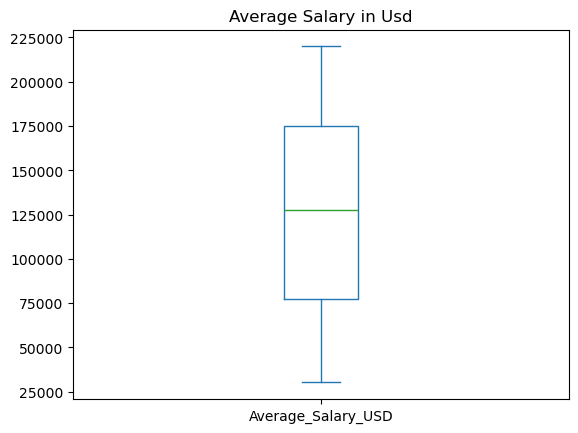

In [19]:
#all records seem to be within a valid range
#Outlier Detection
#Average Salary_Usd
df['Average_Salary_USD'].plot(kind='box', title='Average Salary in Usd')
plt.show()

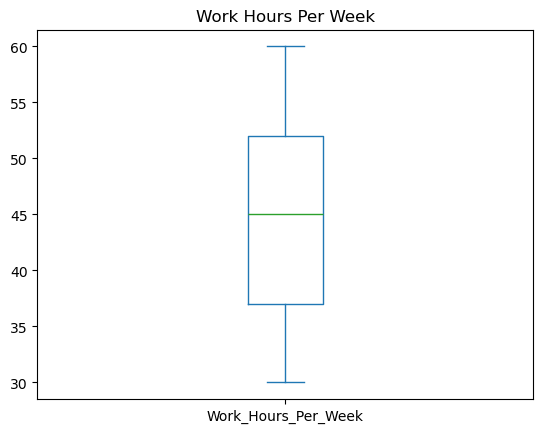

In [20]:
df['Work_Hours_Per_Week'].plot(kind='box', title='Work Hours Per Week')
plt.show()

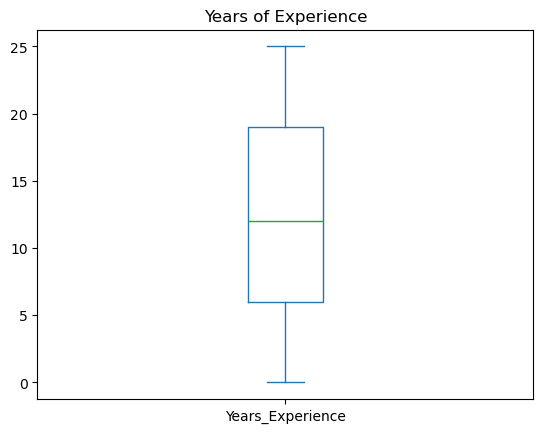

In [21]:
df['Years_Experience'].plot(kind='box', title='Years of Experience')
plt.show()

In [22]:
#There are no outliers shown by the box plot, as the given code would mark outliers
#so there is no need to remove outliers

In [23]:
#Part C: Exploratory Data Analysis(EDA)
#.17: Highest AI Replacement Risk
df.head()
result = df.groupby('Industry')['Automation_Level'].value_counts().reset_index()
print(result)

          Industry Automation_Level  count
0        Education           Medium    104
1        Education             High     99
2        Education              Low     97
3           Energy              Low    123
4           Energy             High    109
5           Energy           Medium    103
6          Finance              Low    108
7          Finance           Medium    107
8          Finance             High     95
9       Government           Medium    120
10      Government             High    102
11      Government              Low    101
12      Healthcare              Low     98
13      Healthcare             High     88
14      Healthcare           Medium     87
15   Manufacturing           Medium    104
16   Manufacturing             High    102
17   Manufacturing              Low     97
18           Media              Low    105
19           Media           Medium     95
20           Media             High     87
21          Retail              Low    105
22         

In [24]:
#countries with highest average salaries
result = df.groupby('Country')['Average_Salary_USD'].mean().reset_index()
print(result)

     Country  Average_Salary_USD
0  Australia       129039.266026
1     Canada       123726.445614
2    Germany       128440.735849
3      India       125810.670251
4      Japan       122355.133779
5   Pakistan       122865.546667
6  Singapore       130980.434457
7        UAE       126109.204611
8         UK       133214.812081
9        USA       124013.857627


In [25]:
df.head()

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


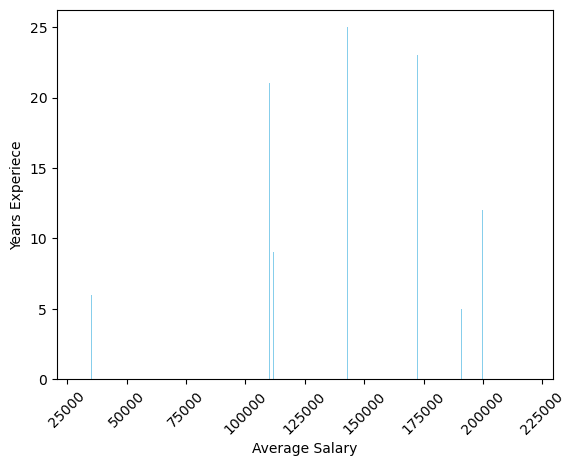

In [26]:
#relationship between years experience and salary
#honestly, feels like a bar chart would apply here rather than just like, using a few group by
plt.bar(df["Average_Salary_USD"], df["Years_Experience"], color="skyblue")

plt.title("")
plt.xlabel("Average Salary")
plt.ylabel("Years Experiece")
plt.xticks(rotation=45)
plt.show()

In [27]:
df.groupby("AI_Tool_Usage")["Company_Size"].value_counts().reset_index()

,AI_Tool_Usage,Company_Size,count
0,High,Startup,350
1,High,Enterprise,333
2,High,Medium,331
3,Low,Medium,364
4,Low,Enterprise,340
5,Low,Startup,329
6,Moderate,Medium,330
7,Moderate,Enterprise,317
8,Moderate,Startup,306


In [28]:
#highest future demand score
df.sort_values(['Job_Title','Future_Demand_Score'],ascending=False).groupby('Job_Title').head(20)

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
223,AIJ-100223,UX Designer,Transportation,UK,Master,12,0.49,0.98,Yes,180606,"AWS, Excel, Leadership",High,-2,31,Enterprise,Moderate,3.43,Yes,3.01,Stable
329,AIJ-100329,UX Designer,Finance,UAE,High School,3,0.91,0.98,No,164064,"TensorFlow, Excel, AWS, Leadership, Project Ma...",Medium,21,37,Enterprise,Low,2.09,Yes,4.32,Stable
1481,AIJ-101481,UX Designer,Energy,Canada,High School,23,0.06,0.98,Yes,159982,"Cybersecurity, Docker, Deep Learning",High,43,48,Enterprise,High,3.44,Yes,2.87,Growing
831,AIJ-100831,UX Designer,Transportation,UK,PhD,4,0.28,0.97,Hybrid,177335,"Data Visualization, Kubernetes, Excel, Deep Le...",Low,10,34,Enterprise,Low,3.53,No,2.53,Growing
966,AIJ-100966,UX Designer,Manufacturing,UK,Master,23,0.14,0.97,Yes,191808,"Project Management, SQL, Deep Learning, Kubern...",Medium,-4,35,Startup,Low,4.72,No,3.99,Declining
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,AIJ-100105,AI Engineer,Energy,Japan,High School,7,0.22,0.89,Yes,59581,"Azure, Excel, Cybersecurity, AWS",Low,-4,49,Startup,Moderate,3.79,Yes,1.98,Declining
2287,AIJ-102287,AI Engineer,Manufacturing,Pakistan,Bachelor,1,0.47,0.89,No,97232,"SQL, Cybersecurity, Deep Learning, Data Visual...",Low,-3,37,Enterprise,Low,2.01,No,3.62,Growing
1798,AIJ-101798,AI Engineer,Government,Germany,High School,17,0.87,0.87,Hybrid,43953,"Python, Cybersecurity, AWS, Machine Learning, ...",Low,8,50,Enterprise,High,3.92,Yes,4.35,Declining
70,AIJ-100070,AI Engineer,Manufacturing,Japan,Bachelor,19,0.74,0.86,No,168027,"Machine Learning, Project Management, Cloud Co...",Low,0,35,Enterprise,High,4.43,Yes,3.88,Declining


In [29]:
df.groupby("Education_Level")["Job_Satisfaction"].mean().reset_index()

,Education_Level,Job_Satisfaction
0,Bachelor,3.046176
1,High School,3.135488
2,Master,2.935000
3,PhD,2.987381


In [30]:
hiring_trend = df.groupby("Hiring_Trend_2026")['Industry'].value_counts()

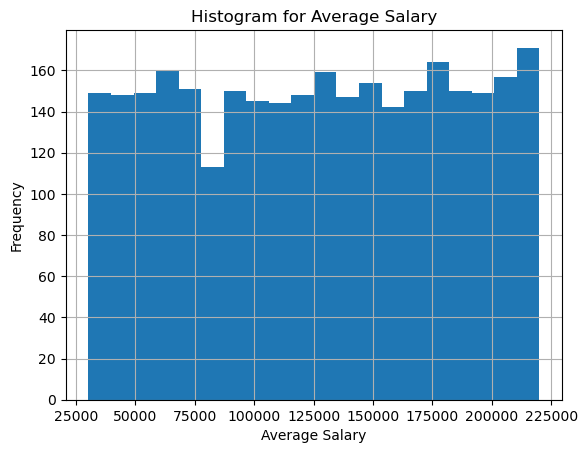

In [31]:
#Part D: Data Visualization
hist = df['Average_Salary_USD'].hist(bins=20)

# Adding title and labels
plt.title('Histogram for Average Salary')
plt.xlabel('Average Salary')
plt.ylabel('Frequency')

# Display the histogram
plt.show()

<Axes: title={'center': 'Average_Salary_USD'}, xlabel='Industry'>

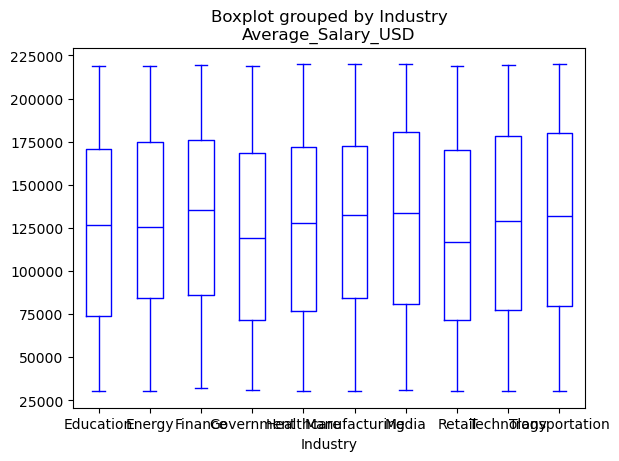

In [32]:
df.boxplot(column=['Average_Salary_USD'], by='Industry', grid=False, color='blue')


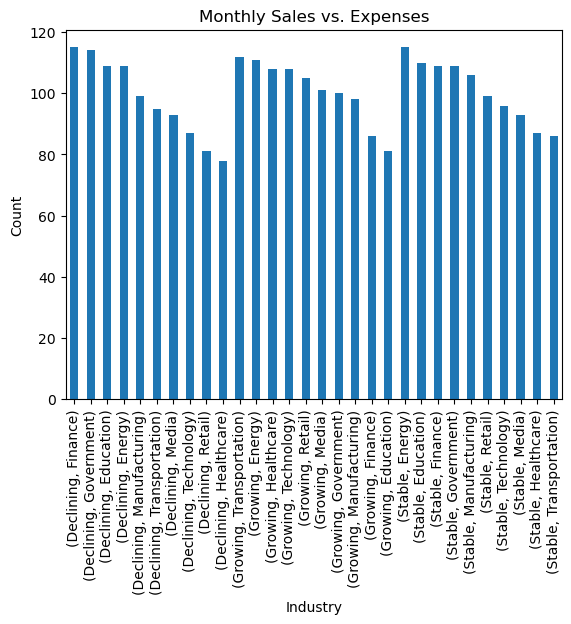

In [33]:
hiring_trend.plot.bar(title='Monthly Sales vs. Expenses')
plt.ylabel('Count')
plt.xlabel('Industry')
plt.show()

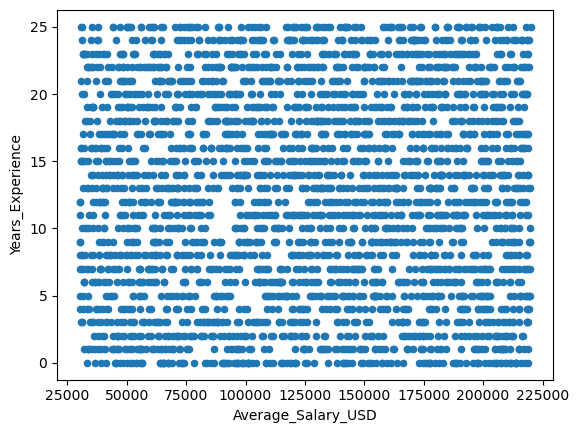

In [34]:

df.plot.scatter(x='Average_Salary_USD', y='Years_Experience')

plt.show()

In [35]:
#heatmap
#we first need to just get the numeric columns
df2 = df[['Years_Experience','AI_Replacement_Risk','Future_Demand_Score','Average_Salary_USD','Job_Growth_2030','Work_Hours_Per_Week','Performance_Score','Job_Satisfaction']]
df2

,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Average_Salary_USD,Job_Growth_2030,Work_Hours_Per_Week,Performance_Score,Job_Satisfaction
0,1,0.25,0.78,207392,3,37,2.08,3.86
1,24,0.73,0.33,140785,-5,42,4.54,4.23
2,21,0.80,0.69,124800,-5,57,3.14,3.54
3,5,0.29,0.94,199878,7,59,3.67,4.37
4,20,0.11,0.92,178682,6,34,3.68,3.99
...,...,...,...,...,...,...,...,...
2995,0,0.62,0.27,202565,36,59,4.54,1.27
2996,4,0.52,0.57,37215,17,45,2.71,2.56
2997,7,0.72,0.70,55179,34,35,4.88,3.17
2998,19,0.82,0.76,125291,21,47,3.59,3.78


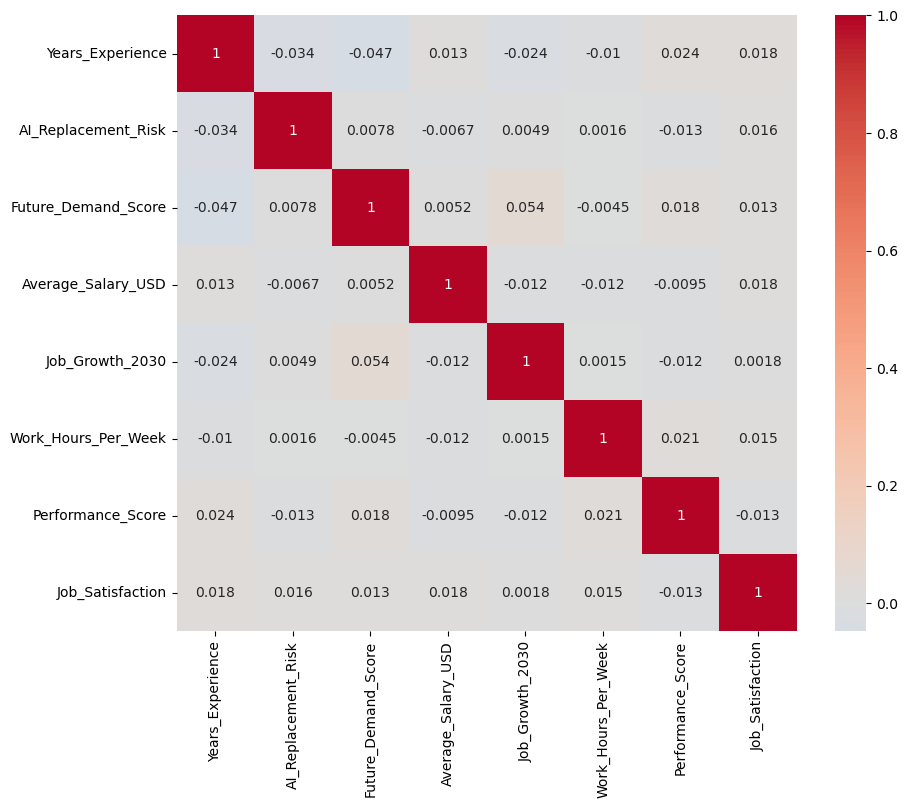

In [36]:
corr = df2.corr()

# Generating the heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.show()

In [37]:
df.head(10)

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable
5,AIJ-100005,Machine Learning Engineer,Energy,Japan,High School,12,0.73,0.88,No,70066,"Excel, Deep Learning, Cybersecurity, Communica...",High,19,46,Medium,High,4.58,Yes,3.72,Declining
6,AIJ-100006,UX Designer,Media,UK,High School,20,0.46,0.95,No,218659,"Leadership, Cloud Computing, Project Managemen...",High,22,49,Startup,Low,3.12,Yes,3.16,Growing
7,AIJ-100007,Digital Marketer,Technology,Germany,High School,2,0.15,0.49,Hybrid,110612,"Leadership, AWS, Python",Medium,42,32,Enterprise,Low,2.39,No,4.79,Declining
8,AIJ-100008,Robotics Engineer,Energy,Pakistan,PhD,16,0.73,0.74,No,216895,"Docker, PyTorch, Prompt Engineering, Azure, Co...",Low,5,37,Startup,Moderate,2.06,Yes,3.35,Declining
9,AIJ-100009,Product Manager,Education,India,PhD,6,0.86,0.88,Hybrid,48574,"SQL, Deep Learning, Machine Learning",Low,36,59,Enterprise,High,3.42,No,4.23,Declining


In [38]:
#PART E: Feature Engineering
#converting categorical variables into numerical format using one hot encoding/label encoding
#label encoding here would work since we need to turn them numeric
#
#i think i'll just use it for all because the feature scalling of one hot for the others would be bad 
le = LabelEncoder()
df['Company_Size'] = le.fit_transform(df["Company_Size"])
print(df)
df['Hiring_Trend_2026'] = le.fit_transform(df["Hiring_Trend_2026"])
print(df)
df["Upskilling_Needed"] = le.fit_transform(df["Upskilling_Needed"])
print(df)
df["AI_Tool_Usage"] = le.fit_transform(df["AI_Tool_Usage"])
print(df)
df["Automation_Level"] = le.fit_transform(df["Automation_Level"])
print(df)
df["Remote_Work_Possibility"] = le.fit_transform(df["Remote_Work_Possibility"])
print(df)
df["Education_Level"] = le.fit_transform(df["Education_Level"])
print(df)
df["Country"] = le.fit_transform(df["Country"])
print(df)
df['Industry'] = le.fit_transform(df["Industry"])
print(df)
df["Job_Title"] = le.fit_transform(df["Job_Title"])
print(df)

     Employee_ID              Job_Title    Industry    Country  \
0     AIJ-100000          Data Engineer  Healthcare      Japan   
1     AIJ-100001     Healthcare Analyst      Retail         UK   
2     AIJ-100002          HR Specialist   Education     Canada   
3     AIJ-100003  Cybersecurity Analyst  Government         UK   
4     AIJ-100004     Healthcare Analyst   Education        UAE   
...          ...                    ...         ...        ...   
2995  AIJ-102995         Data Scientist   Education      India   
2996  AIJ-102996          Data Engineer  Healthcare        UAE   
2997  AIJ-102997        DevOps Engineer      Energy   Pakistan   
2998  AIJ-102998         Data Scientist  Government  Australia   
2999  AIJ-102999          HR Specialist      Retail    Germany   

     Education_Level  Years_Experience  AI_Replacement_Risk  \
0                PhD                 1                 0.25   
1           Bachelor                24                 0.73   
2        High Scho

In [39]:
#salary classification based on average_salary_usd
#under 99,999  >100,000 <199,999

df.loc[df['Average_Salary_USD']>= 200000,'Salary'] = "High"
df.loc[(df["Average_Salary_USD"] <200000), 'Salary'] = "Medium"
df.loc[df["Average_Salary_USD"]<100000, 'Salary'] = "Short"

df['Salary'] = le.fit_transform(df['Salary'])


In [45]:
#i think the main issue is with this code here
#this should be having 0s and 1s
#if i fix it, i think the rest of the code will not have issues


df.loc[df['AI_Replacement_Risk']>0.5,'High_Risk'] = 1
df.loc[df["AI_Replacement_Risk"]<0.5,'High_Risk'] = 0
print(df)
df

     Employee_ID  Job_Title  Industry  Country  Education_Level  \
0     AIJ-100000          5         4        4                3   
1     AIJ-100001         11         7        8                0   
2     AIJ-100002         10         0        1                1   
3     AIJ-100003          4         3        8                0   
4     AIJ-100004         11         0        7                3   
...          ...        ...       ...      ...              ...   
2995  AIJ-102995          6         0        3                0   
2996  AIJ-102996          5         4        7                3   
2997  AIJ-102997          7         1        5                1   
2998  AIJ-102998          6         3        0                0   
2999  AIJ-102999         10         7        2                2   

      Years_Experience  AI_Replacement_Risk  Future_Demand_Score  \
0                    1                 0.25                 0.78   
1                   24                 0.73                

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,...,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026,Salary,High_Risk
0,AIJ-100000,5,4,4,3,1,0.25,0.78,2,207392,...,3,37,0,0,2.08,1,3.86,1,0,0.0
1,AIJ-100001,11,7,8,0,24,0.73,0.33,1,140785,...,-5,42,2,2,4.54,0,4.23,1,1,1.0
2,AIJ-100002,10,0,1,1,21,0.80,0.69,2,124800,...,-5,57,2,1,3.14,0,3.54,2,1,1.0
3,AIJ-100003,4,3,8,0,5,0.29,0.94,1,199878,...,7,59,0,0,3.67,0,4.37,0,1,0.0
4,AIJ-100004,11,0,7,3,20,0.11,0.92,1,178682,...,6,34,2,0,3.68,0,3.99,2,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,AIJ-102995,6,0,3,0,0,0.62,0.27,0,202565,...,36,59,0,2,4.54,1,1.27,2,0,1.0
2996,AIJ-102996,5,4,7,3,4,0.52,0.57,2,37215,...,17,45,2,1,2.71,0,2.56,2,2,1.0
2997,AIJ-102997,7,1,5,1,7,0.72,0.70,1,55179,...,34,35,2,1,4.88,1,3.17,0,2,1.0
2998,AIJ-102998,6,3,0,0,19,0.82,0.76,0,125291,...,21,47,2,2,3.59,1,3.78,2,1,1.0


In [46]:
#Part F
currentdf = df.drop(['Employee_ID','Required_Skills'],axis=1)


In [47]:
#after dropping all non relvant columns, and just having numeric data, we can do the prediction
#create x and y
#all numerical features have been standardized

currentdf.info()
X = currentdf.drop("High_Risk", axis=1)
y = currentdf['High_Risk']
print(X)
print(y)
# from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Job_Title                3000 non-null   int64  
 1   Industry                 3000 non-null   int64  
 2   Country                  3000 non-null   int64  
 3   Education_Level          3000 non-null   int64  
 4   Years_Experience         3000 non-null   int64  
 5   AI_Replacement_Risk      3000 non-null   float64
 6   Future_Demand_Score      3000 non-null   float64
 7   Remote_Work_Possibility  3000 non-null   int64  
 8   Average_Salary_USD       3000 non-null   int64  
 9   Automation_Level         3000 non-null   int64  
 10  Job_Growth_2030          3000 non-null   int64  
 11  Work_Hours_Per_Week      3000 non-null   int64  
 12  Company_Size             3000 non-null   int64  
 13  AI_Tool_Usage            3000 non-null   int64  
 14  Performance_Score       

In [48]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
model = LogisticRegression(max_iter=1000, solver="liblinear")

# Train the model
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

ValueError: Input y contains NaN.

In [ ]:
#accuracy of logistic Regression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy : {accuracy}")
print(f"Precision : {precision}")
print(f"recall : {recall}")
print(f"f1score: {f1}")
print(f"confusion Matrix :")
print(conf_matrix)

Accuracy : 0.9816666666666667
Precision : 0.9808917197452229
recall : 0.9840255591054313
f1score: 0.9824561403508771
confusion Matrix :
[[281   6]
 [  5 308]]


In [ ]:
#Model 3 Decsision Tree 
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree model
tree_model = DecisionTreeClassifier(random_state=42)

# Train the model
tree_model.fit(X_train, y_train)

# Make predictions
y_pred_tree = tree_model.predict(X_test)

# Evaluate the Decision Tree model
accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)

print(f"Decision Tree Accuracy : {accuracy_tree}")
print(f"Decision Tree Precision : {precision_tree}")
print(f"Decision Tree Recall : {recall_tree}")
print(f"Decision Tree F1 Score : {f1_tree}")
print("Decision Tree Confusion Matrix:")
print(conf_matrix_tree)

Decision Tree Accuracy : 1.0
Decision Tree Precision : 1.0
Decision Tree Recall : 1.0
Decision Tree F1 Score : 1.0
Decision Tree Confusion Matrix:
[[287   0]
 [  0 313]]


In [44]:
from sklearn.ensemble import RandomForestClassifier

classifier = RandomForestClassifier(n_estimators=100, random_state=42)

classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

ValueError: Input y contains NaN.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#Evaluate the model's performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy : {accuracy}")
print(f"Precision : {precision}")
print(f"recall : {recall}")
print(f"f1score: {f1}")
print(f"confusion Matrix :")
print(conf_matrix)

Accuracy : 0.9816666666666667
Precision : 0.9808917197452229
recall : 0.9840255591054313
f1score: 0.9824561403508771
confusion Matrix :
[[281   6]
 [  5 308]]


In [ ]:
#from this we can determine the best performing model is Random Forest
#Advanced Analysis and Conclusion
#To be frank, because of how i numerically converted the entire dataframe to make it possible to anaylyse it, i'm at a loss for how to quantify or check the details of which factors can be analysed.
#So i have left those sections.
